In [21]:
!pip install datasets transformers wandb huggingface_hub

In [22]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [23]:
from datasets import load_dataset

dataset = load_dataset("Chiranjeev007/STL-10_Subset")

train_data = dataset["train"]
val_data = dataset["validation"]
test_data = dataset["test"]

print(dataset)

DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 5000
    })
    validation: Dataset({
        features: ['image', 'label'],
        num_rows: 500
    })
    test: Dataset({
        features: ['image', 'label'],
        num_rows: 1000
    })
})


In [24]:
from torchvision import transforms
import torch

transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

class STL10Dataset(torch.utils.data.Dataset):
    def __init__(self, hf_dataset, transform=None):
        self.dataset = hf_dataset
        self.transform = transform

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        image = self.dataset[idx]["image"]
        label = self.dataset[idx]["label"]

        if self.transform:
            image = self.transform(image)

        return image, label


In [25]:
from torch.utils.data import DataLoader

train_loader = DataLoader(STL10Dataset(train_data, transform), batch_size=32, shuffle=True)
val_loader = DataLoader(STL10Dataset(val_data, transform), batch_size=32, shuffle=False)
test_loader = DataLoader(STL10Dataset(test_data, transform), batch_size=32, shuffle=False)

In [26]:
import torchvision.models as models
import torch.nn as nn

model = models.resnet18(pretrained=True)
model.fc = nn.Linear(model.fc.in_features, 10)
model = model.to(device)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [27]:
import wandb
wandb.login()
wandb.init(project="stl10-colab")
def unnormalize(img):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
    img = img * std + mean
    return torch.clamp(img, 0, 1)


wandb: WARNING Calling wandb.login() after wandb.init() has no effect.


train_accuracy,▁▃▄▅▆▇██▇▇
train_loss,█▆▅▄▃▂▂▁▂▂
val_accuracy,▁▂▇▂▅▆█▇▆▅
train_accuracy,95.6
train_loss,20.32127
val_accuracy,79.4


In [17]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

EPOCHS = 10
best_val_acc = 0

for epoch in range(EPOCHS):
    model.train()
    train_correct = 0
    train_total = 0
    train_loss = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        _, preds = torch.max(outputs, 1)
        train_total += labels.size(0)
        train_correct += (preds == labels).sum().item()

    train_acc = 100 * train_correct / train_total

    # Validation
    model.eval()
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            val_total += labels.size(0)
            val_correct += (preds == labels).sum().item()

    val_acc = 100 * val_correct / val_total

    wandb.log({
        "train_loss": train_loss,
        "train_accuracy": train_acc,
        "val_accuracy": val_acc
    })

    print(f"Epoch {epoch+1} | Train Acc: {train_acc:.2f}% | Val Acc: {val_acc:.2f}%")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "best_model.pth")

Epoch 1 | Train Acc: 86.70% | Val Acc: 74.40%
Epoch 2 | Train Acc: 89.94% | Val Acc: 75.40%
Epoch 3 | Train Acc: 91.62% | Val Acc: 82.20%
Epoch 4 | Train Acc: 93.00% | Val Acc: 76.20%
Epoch 5 | Train Acc: 93.42% | Val Acc: 80.00%
Epoch 6 | Train Acc: 95.10% | Val Acc: 81.60%
Epoch 7 | Train Acc: 96.16% | Val Acc: 83.80%
Epoch 8 | Train Acc: 96.76% | Val Acc: 82.00%
Epoch 9 | Train Acc: 95.68% | Val Acc: 81.00%
Epoch 10 | Train Acc: 95.60% | Val Acc: 79.40%


In [18]:
from sklearn.metrics import confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

model.load_state_dict(torch.load("best_model.pth"))
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

test_acc = accuracy_score(all_labels, all_preds)
print("Test Accuracy:", test_acc * 100)

Test Accuracy: 83.7


Class 0 Accuracy: 89.00%
Class 1 Accuracy: 98.00%
Class 2 Accuracy: 92.00%
Class 3 Accuracy: 94.00%
Class 4 Accuracy: 78.00%
Class 5 Accuracy: 50.00%
Class 6 Accuracy: 90.00%
Class 7 Accuracy: 74.00%
Class 8 Accuracy: 85.00%
Class 9 Accuracy: 87.00%


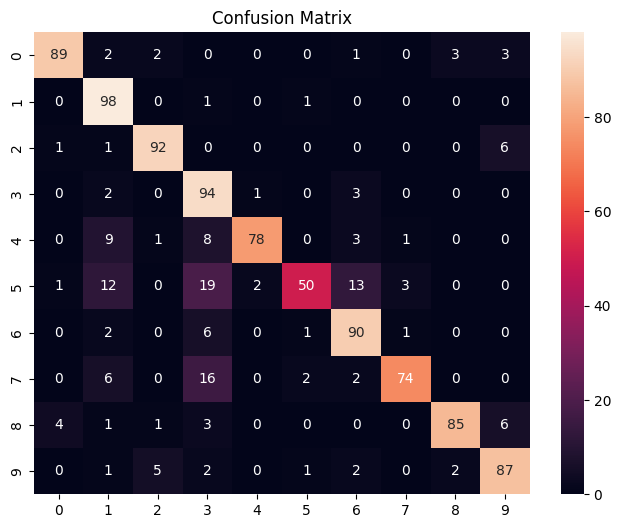

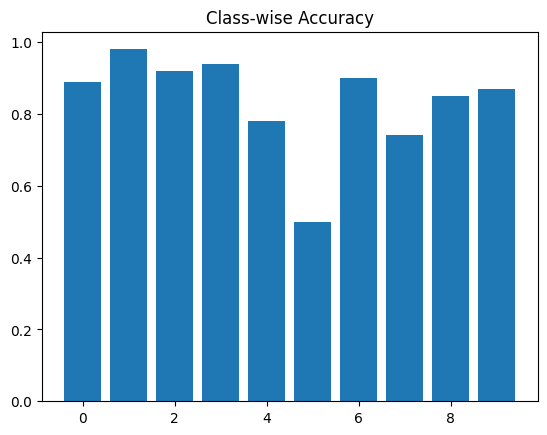

In [19]:
cm = confusion_matrix(all_labels, all_preds)

class_acc = cm.diagonal() / cm.sum(axis=1)

for i, acc in enumerate(class_acc):
    print(f"Class {i} Accuracy: {acc*100:.2f}%")

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()

plt.bar(range(10), class_acc)
plt.title("Class-wise Accuracy")
plt.show()

In [20]:
correct_images.append(
    wandb.Image(
        unnormalize(img.cpu()),
        caption=f"Pred:{pred.item()}, True:{label.item()}"
    )
)

In [28]:
correct_images = []
incorrect_images = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        for img, pred, label in zip(images, preds, labels):
            if pred == label and len(correct_images) < 10:
                correct_images.append(
    wandb.Image(
        unnormalize(img.cpu()),
        caption=f"Pred:{pred.item()}, True:{label.item()}"
    )
)
            elif pred != label and len(incorrect_images) < 10:
                incorrect_images.append(wandb.Image(img.cpu(), caption=f"Pred:{pred}, True:{label}"))

            if len(correct_images) == 10 and len(incorrect_images) == 10:
                break

wandb.log({
    "Correct Predictions": correct_images,
    "Incorrect Predictions": incorrect_images
})